<a href="https://colab.research.google.com/github/keshav123333/langgraph/blob/main/lecture8_Conditional_worflow/lecture8_Conditional_worflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install langchain-huggingFace langgraph


In [3]:
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace

llm=HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    task="text-generation",


    temperature=0.7
)

model=ChatHuggingFace(llm=llm)

In [4]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
class QuadState(TypedDict):

    a: int
    b: int
    c: int

    equation: str
    discriminant: float
    result: str

In [13]:
def show_equation(state: QuadState):

    equation = f'{state["a"]}x2{state["b"]}x{state["c"]}'

    return {'equation':equation}

def calculate_discriminant(state: QuadState):

    discriminant = state["b"]**2 - (4*state["a"]*state["c"])

    return {'discriminant': discriminant}

def real_roots(state: QuadState):

    root1 = (-state["b"] + state["discriminant"]**0.5)/(2*state["a"])
    root2 = (-state["b"] - state["discriminant"]**0.5)/(2*state["a"])

    result = f'The roots are {root1} and {root2}'

    return {'result': result}

def repeated_roots(state: QuadState):

    root = (-state["b"])/(2*state["a"])

    result = f'Only repeating root is {root}'

    return {'result': result}

def no_real_roots(state: QuadState):

    result = f'No real roots'

    return {'result': result}

# meri baat samjh jab ye func call toh literals means ye ye hi cheeze return karega so ab sun isme se discriminant ke hisab se quad return
# ye jo cheez return unke name niche diye nodes ke name se mathc as ye jo return uss name ki node ke pas flow ho jayega workflow

def check_condition(state: QuadState) -> Literal["real_roots", "repeated_roots", "no_real_roots"]:

    if state['discriminant'] > 0:
        return "real_roots"
    elif state['discriminant'] == 0:
        return "repeated_roots"
    else:
        return "no_real_roots"

In [14]:
graph = StateGraph(QuadState)
graph.add_node('show_equation', show_equation)
graph.add_node('calculate_discriminant', calculate_discriminant)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('no_real_roots', no_real_roots)


graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_discriminant')
# cal discriminant ne check condition ko call vo check ki discriminant kaisa uss hisab se fir check condition ki jagah dusre node ka name aa jayega jo codnition ko satisfy

graph.add_conditional_edges('calculate_discriminant', check_condition)
graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('no_real_roots', END)

workflow = graph.compile()

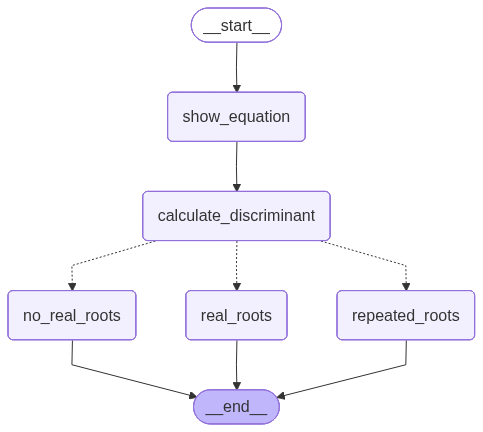

In [15]:
workflow

In [16]:
initial_state = {
    'a': 2,
    'b': 4,
    'c': 2
}

workflow.invoke(initial_state)

{'a': 2,
 'b': 4,
 'c': 2,
 'equation': '2x24x2',
 'discriminant': 0,
 'result': 'Only repeating root is -1.0'}

# Flow to find sentiment analysis of a product



## Structred model

In [17]:
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field
from langchain_core.output_parsers import PydanticOutputParser

In [18]:
class SentimentSchema(BaseModel):

    sentiment: Literal["positive", "negative"] = Field(description='Sentiment of the review')

In [19]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [21]:
parser=PydanticOutputParser(pydantic_object=SentimentSchema)
parser2=PydanticOutputParser(pydantic_object=DiagnosisSchema)

In [22]:
template=PromptTemplate(
    template="can u give me the sentiment of this review is this review postive or negative {review} /n {format_instruction}",
    input_variables=["review"],
    partial_variables={"format_instruction":parser.get_format_instructions()}
)

template2=PromptTemplate(
    template="can u give me  diagonosis of   this review like in what is problem in proper given format {review} /n {format_instruction}",
    input_variables=["review"],
    partial_variables={"format_instruction":parser2.get_format_instructions()}
)


In [23]:
structured_model = template | model | parser
structured_model2 = template2 | model |parser2

In [24]:
structured_model.invoke({"review":"fuck this is shit"})


SentimentSchema(sentiment='negative')

In [25]:
structured_model2.invoke({"review":"fuck this is shit"})

DiagnosisSchema(issue_type='Other', tone='angry', urgency='high')

# workflow

In [26]:
class ReviewState(TypedDict):
  review:str
  sentiment:Literal["positive","negative"]
  diagnosis:dict
  response:str

In [28]:
def find_sentiment(state:ReviewState):

  prompt = f'For the following review find out the sentiment \n {state["review"]}'
  sentiment=structured_model.invoke({"review":prompt}).sentiment

  return {"sentiment":sentiment}

def checkSentiment(state:ReviewState)->Literal["run_diagnosis","postive_response"]:
  if state.get("sentiment")=="postive":
    return "postive_response"
  else:
    return "run_diagnosis"

def run_diagnosis(state:ReviewState):
   prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency."""
   response=structured_model2.invoke({"review":prompt})
   return {"diagnosis":response.model_dump()} # model_dump dict deta hai output mein

def postive_response(state:ReviewState):
  prompt=f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
  Also, kindly ask the user to leave feedback on our website."""
  response=model.invoke(prompt).content
  return {"response":response}


def negative_response(state: ReviewState):

    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message. /n
And this is user review = {state.get("review")}
"""
    response = model.invoke(prompt).content

    return {'response': response}


In [29]:
graph=StateGraph(ReviewState)

graph.add_node("find_sentiment",find_sentiment)
graph.add_node("run_diagnosis",run_diagnosis)
graph.add_node("negative_response",negative_response)
graph.add_node("postive_response",postive_response)


#connected

graph.add_edge(START,"find_sentiment")
#ek aur baa jaise mera plan tha ki sentiment choose karne ke baad pos toh pos res and bas but if neg
# toh run diagnosis and neg response taiyaar kar then end toh tujhe dono case ke liye node toh banai padegi flow kis node se jata
#  maan postive toh postive wali edges se end pe jayega if nega th neg wali edge se end pe jayega
# banai sari padgi
graph.add_conditional_edges("find_sentiment",checkSentiment) # ifcheckSentiment pos toh ye niche wali edhge chelegi
# ifcheckSentiment pos toh ye niche wali edhge chelegi

graph.add_edge("postive_response",END)

#if checkSentiment neg toh ye wali edge

graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

workflow = graph.compile()


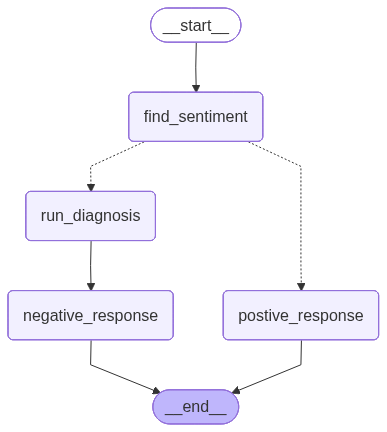

In [30]:
workflow

In [31]:
intial_state={
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}
workflow.invoke(intial_state)

{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'frustrated', 'urgency': 'high'},
 'response': "Dear valued user,\n\nI'm truly sorry to hear that you've been experiencing issues with logging in to our app. I can imagine how frustrating it must be to encounter a problem that's preventing you from accessing basic functionality.\n\nI want to assure you that I'm here to help and I'm taking your issue very seriously. I've checked our system logs and it seems that there might be a temporary glitch that's causing the authentication screen to freeze.\n\nTo resolve this issue, I'd like to provide you with a few options:\n\n1. **Temporary workaround:** Try clearing the app's cache and data on your device. This might help resolve the 